# ALTR walkthrough

A guided, executable tour of the ALTR model. It runs the **whole pipeline** on the
committed fixture slice — five power companies and one WITCH scenario pair, about
15 seconds per run — then opens each stage's output in turn and finishes with a
parameter experiment.

Nothing here is a special demo path: it is the same code, the same config and the
same node graph a full-data run uses. Only the input data is smaller.

## How this maps to the documentation

| Docs page | What it covers | Where it shows up below |
|---|---|---|
| `quickstart.md` | install → data → run → outputs | Section 1 |
| `architecture.md` | the eight stages and the data flow between them | Section 2 |
| `pipelines/*.md` | one page per stage: purpose, datasets, key functions | Section 2, per checkpoint |
| `parameters.md` | every run parameter, generated from `conf/base/parameters.yml` | Section 3 |
| `user_guide.md` | a worked run with the headline output tables | Sections 2 and 3 |

## What you need

The repository installed into a Python 3.10 environment (`pip install -e .`).
No external data: the inputs live in `tests/fixtures/data/` and ship with the
repository. Outputs are written to `data/fixture_run/`, which is quarantined from
the real `data/07_model_output/` tree, so running this notebook can never
overwrite a production run.

In [1]:
# Silence the pipeline's own logging BEFORE importing Kedro — Kedro configures
# logging at import time, so the order of these two lines matters.
import logging

logging.disable(logging.WARNING)

import contextlib
import io
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from kedro.framework.session import KedroSession
from kedro.framework.startup import bootstrap_project

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

# Works whether the notebook is run from notebooks/ or from the project root.
PROJECT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists())
FIXTURE_OUT = PROJECT / "data" / "fixture_run"

_boot = io.StringIO()
with contextlib.redirect_stdout(_boot), contextlib.redirect_stderr(_boot):
    bootstrap_project(PROJECT)

# Kedro's rich logging handler takes over IPython's plain-text repr on the way in;
# hand it back so the tables below render as ordinary DataFrames.
try:
    get_ipython().display_formatter.formatters["text/plain"].pprint = False  # noqa: F821
except (NameError, AttributeError):  # not running under IPython
    pass


def run_altr(**overrides) -> float:
    """Run the eight ALTR stages on the fixture slice; return wall-clock seconds.

    ``overrides`` are Kedro ``extra_params``: they take precedence over
    ``conf/base/parameters.yml`` for this run only, which is how the parameter
    experiment in Section 3 works without editing any file.
    """
    started = time.perf_counter()
    chatter = io.StringIO()
    with contextlib.redirect_stdout(chatter), contextlib.redirect_stderr(chatter):
        with KedroSession.create(
            project_path=PROJECT, env="fixture", extra_params=overrides
        ) as session:
            session.run(tags=["altrisk"])
    return time.perf_counter() - started


def read_output(relative_path: str) -> pd.DataFrame:
    """Read one CSV written by the last run, e.g. ``07_model_output/company_npv.csv``."""
    return pd.read_csv(FIXTURE_OUT / relative_path, low_memory=False)

## 1. Run the model

`kedro run --env fixture --tags altrisk` on the command line does exactly what the
next cell does programmatically. Two things are worth unpacking:

- **`--env fixture`** swaps in `conf/fixture/`, which points the three input
  datasets at the committed slice and redirects every output under
  `data/fixture_run/`. Everything else is inherited from `conf/base/`.
- **`--tags altrisk`** selects the eight model stages and skips the `reporting`
  pipeline, which is tagged `reporting` and runs separately.

For a full-data run the command is `kedro run --tags altrisk` with no `--env`.

In [2]:
seconds = run_altr()
produced = sorted(p.relative_to(FIXTURE_OUT).as_posix() for p in FIXTURE_OUT.rglob("*.csv"))
print(f"run finished in {seconds:.1f}s, {len(produced)} tables written under data/fixture_run/\n")
print("\n".join(produced))

run finished in 12.2s, 16 tables written under data/fixture_run/

05_model_output/scenarios_pathways.csv
07_model_output/allocated_assets_to_companies.csv
07_model_output/asset_earnings.csv
07_model_output/asset_level_staggered_shock.csv
07_model_output/asset_npv.csv
07_model_output/companies_late_sudden_trajectories.csv
07_model_output/company_npv.csv
07_model_output/company_technology_npv.csv
07_model_output/frozen_capacity_at_retirement.csv
07_model_output/yearly_npv_trajectories.csv
08_reporting/tables/compliance_ready/company_summary.csv
08_reporting/tables/compliance_ready/methodology_parameters.csv
08_reporting/tables/compliance_ready/reporting_qc.csv
08_reporting/tables/compliance_ready/technology_summary.csv
08_reporting/tables/compliance_ready/top_assets.csv
08_reporting/tables/validation_summary.csv


## 2. Following the data through the eight stages

Each stage hands the next one a table. Six of those tables are persisted, and they
are enough to see the whole mechanism:

| # | Stage | Checkpoint below |
|---|---|---|
| 1 | `inputs_processing` | scenario pathways, allocated assets |
| 2 | `inputs_postproc` | (feeds the trajectory stages) |
| 3 | `create_baseline_and_target_trajectories` | company trajectories |
| 4 | `create_late_sudden_trajectories` | company trajectories (`latesudden`) |
| 5 | `distribute_impacts_to_asset_level` | asset-level staggered shock |
| 6 | `earnings_model` | asset earnings |
| 7 | `valuation_model` | asset / company NPV |
| 8 | `reporting` | not run here (`--tags altrisk` excludes it) |

### Checkpoint 1 — scenario pathways (stage 1)

`inputs_processing` filters the raw IAM scenario table down to the pair named in
`parameters.yml`, labels them `baseline` and `target`, and interpolates to annual
resolution. Everything downstream compares those two worlds.

In [3]:
pathways = read_output("05_model_output/scenarios_pathways.csv")
print(pathways.shape)
pathways[["scenario", "scenario_type"]].drop_duplicates().reset_index(drop=True)

(18720, 23)


,scenario,scenario_type
0,AR6_WITCH 5.0_EN_NPi2020_500,target
1,AR6_WITCH 5.0_EN_NoPolicy,baseline


The `scenario_pathway` column is the production/capacity path each technology is
expected to follow. Comparing a fossil technology with a renewable one shows the
transition the target scenario demands — this gap is the raw material for the
whole model.

In [4]:
pathway_gap = (
    pathways[pathways["technology"].isin(["CoalCap - w/o CCS", "SolarCap - PV"])]
    .pivot_table(
        index="year",
        columns=["technology", "scenario_type"],
        values="scenario_pathway",
        aggfunc="sum",
    )
)
pathway_gap.iloc[::5]

technology    CoalCap - w/o CCS               SolarCap - PV              
scenario_type          baseline        target      baseline        target
year                                                                     
2025               7.409377e+06  6.927658e+06  2.606471e+06  3.702418e+06
2030               7.067139e+06  5.925580e+06  3.717566e+06  7.559152e+06
2035               6.318232e+06  5.068457e+06  5.960199e+06  1.349371e+07
2040               5.564308e+06  4.335321e+06  9.530310e+06  2.114798e+07
2045               4.825160e+06  3.708236e+06  1.389593e+07  2.469960e+07
2050               4.170933e+06  3.171862e+06  2.019042e+07  2.835979e+07

### Checkpoint 2 — assets allocated to companies (stage 1)

The other half of `inputs_processing`: power assets are joined to their owners
through the ownership table and filtered by `ownership_type` (`direct` by default,
i.e. `ownership_level == 1`). Each row is one asset in one year, carrying the
ownership share used later to attribute value.

In [5]:
assets = read_output("07_model_output/allocated_assets_to_companies.csv")
print(f"{assets['company_id'].nunique()} companies, {assets['asset_id'].nunique()} assets, "
      f"years {assets['year'].min()}-{assets['year'].max()}")
assets.groupby(["company_name"]).agg(
    assets=("asset_id", "nunique"),
    technologies=("technology", "nunique"),
    countries=("country_iso2", "nunique"),
)

5 companies, 671 assets, years 2025-2030


,assets,technologies,countries
company_name,,,
ENGIE SA,296,8,26
Electricité de France SA,137,8,14
Kansai Electric Power Co,67,9,5
Tohoku Electric Power Co Inc,52,8,2
Vattenfall AB,124,8,7


### Checkpoint 3 — company trajectories (stages 3 and 4)

Stage 3 builds each company's `baseline` and `target` production path. Stage 4
derives the `latesudden` path: the company follows business-as-usual until
`shock_year`, then has to reach the target by `alignment_year`. The compression of
that adjustment into a few years is the shock the model prices.

The cell picks the company-technology pair where baseline and late-and-sudden
diverge most, so the shape is visible.

In [6]:
trajectories = read_output("07_model_output/companies_late_sudden_trajectories.csv")
wide = trajectories.pivot_table(
    index=["company_name", "technology", "year"],
    columns="trajectory_type",
    values="company_trajectory",
)
gap = (wide["baseline"] - wide["latesudden"]).abs().groupby(level=["company_name", "technology"]).max()
focus_company, focus_tech = gap.idxmax()
print(f"largest divergence: {focus_company} / {focus_tech}")
wide.loc[(focus_company, focus_tech)].iloc[::3]

largest divergence: Electricité de France SA / NuclearCap


trajectory_type,baseline,latesudden,target
year,,,
2025,65690.000000,65690.000000,65690.000000
2028,65690.000000,65690.000000,59991.740823
2031,64065.341464,64065.341464,54563.037694
2034,59186.914738,56256.190187,49684.607211
2037,54779.160784,46979.451075,45276.849862
2040,50610.228523,35080.826242,41107.914390
2043,47406.229439,31513.643805,37540.731953
2046,44310.037890,28117.751155,34144.839304
2049,41429.756778,25064.907367,31091.995515


### Checkpoint 4 — the shock at asset level (stage 5)

`distribute_impacts_to_asset_level` pushes the company-level adjustment down onto
individual assets. `late_sudden_phase` labels what each asset-year is doing:

- `forecast` — inside the reported forecast window, untouched
- `bau` — business as usual, before the shock
- `transition` — carrying the adjustment between shock and alignment year
- `retirement` — capacity taken off the system
- `aligned` / `aligned_compensation` — post-alignment steady state

`allocated_shock` is the capacity change assigned to that asset-year;
`capacity_after_shock = capacity_before_shock + allocated_shock`.

In [7]:
shock = read_output("07_model_output/asset_level_staggered_shock.csv")
by_phase = shock.groupby("late_sudden_phase").agg(
    rows=("asset_id", "size"),
    capacity_before=("capacity_before_shock", "sum"),
    allocated_shock=("allocated_shock", "sum"),
    capacity_after=("capacity_after_shock", "sum"),
)
by_phase.round(0)

,rows,capacity_before,allocated_shock,capacity_after
late_sudden_phase,,,,
aligned,7382,1910909.0,66333.0,1977242.0
aligned_compensation,1252,302996.0,22204.0,325201.0
bau,1452,382255.0,0.0,382255.0
forecast,4325,1055732.0,0.0,1055732.0
retirement,78,42147.0,-42147.0,0.0
transition,4257,1166549.0,37392.0,1203942.0


### Checkpoint 5 — earnings (stage 6)

`earnings_model` turns capacity into money. Per asset-year it computes production
`Q`, applies the scenario power price (adjusted towards a market clearing price by
the MCPR step), subtracts variable, fixed and carbon costs, and adds capex to get
free cash flow to the firm (`FCFF`).

The table is stacked: `trajectory_type` distinguishes the two worlds being valued.

In [8]:
earnings = read_output("07_model_output/asset_earnings.csv")
money = ["revenue", "var_cost", "fixed_cost", "carbon_cost_net", "EBITDA", "capex_total", "FCFF"]
(earnings.groupby("trajectory_type")[money].sum() / 1e9).round(2)

,revenue,var_cost,fixed_cost,carbon_cost_net,EBITDA,capex_total,FCFF
trajectory_type,,,,,,,
baseline,863.57,121.91,470.32,0.00,271.35,317.80,-46.45
latesudden,907.71,102.16,662.61,40.69,102.25,337.35,-235.10


Read down the `FCFF` row: the late-and-sudden world earns less than the baseline
world, and the difference is what the valuation stage discounts. Reading across
tells you *why* — how much of the gap is lost revenue versus added carbon cost
versus capex.

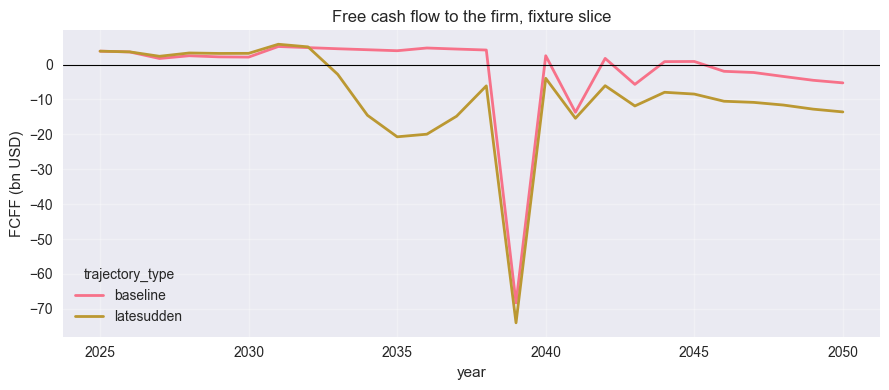

In [9]:
annual = earnings.groupby(["year", "trajectory_type"])["FCFF"].sum().unstack() / 1e9
ax = annual.plot(figsize=(9, 4), lw=2)
ax.set_title("Free cash flow to the firm, fixture slice")
ax.set_ylabel("FCFF (bn USD)")
ax.set_xlabel("year")
ax.axhline(0, color="black", lw=0.8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Two features of that curve are worth naming. The late-and-sudden line drops below
the baseline from the shock year onwards — that gap is the thing being valued. The
2039 spike, on the other hand, is present in *both* worlds and is capex, not
earnings: `capex_total` jumps from roughly 7bn to 77bn that year as a cohort of
assets reaches end of life together and triggers replacement capex
(`include_replacement_capex` is `True` by default). Cohort bunching like this is
easy to hit on a five-company slice; check whether it survives on your full asset
universe before reading anything into a single year.

### Checkpoint 6 — valuation (stage 7)

`valuation_model` discounts each asset's FCFF stream to a net present value under
both trajectories, adds a terminal value, then aggregates asset → company-technology
→ company. `npv_change` is the relative move from baseline to late-and-sudden.

Sign convention: a **negative** `npv_change` means the transition destroys value for
that company; positive means it gains. Companies with a renewables-heavy fleet can
come out ahead.

In [10]:
company_npv = read_output("07_model_output/company_npv.csv").sort_values("npv_change")
company_npv.assign(
    baseline_npv_bn=lambda d: (d["baseline_npv"] / 1e9).round(2),
    latesudden_npv_bn=lambda d: (d["latesudden_npv"] / 1e9).round(2),
    npv_change=lambda d: d["npv_change"].round(3),
)[["company_name", "asset_count", "baseline_npv_bn", "latesudden_npv_bn", "npv_change"]]

,company_name,asset_count,baseline_npv_bn,latesudden_npv_bn,npv_change
2,Electricité de France SA,145,-18.28,-71.11,-2.890
3,Tohoku Electric Power Co Inc,53,5.64,-6.36,-2.127
0,Kansai Electric Power Co,74,-4.99,-7.10,-0.422
1,Vattenfall AB,129,7.56,12.86,0.700
4,ENGIE SA,320,14.24,43.51,2.055


`asset_npv.csv` carries the same comparison one level down, with the cost
components that produced it — the table to open when a company-level number needs
explaining.

In [11]:
asset_npv = read_output("07_model_output/asset_npv.csv")
worst = asset_npv.nsmallest(5, "npv_change")
worst[["asset_name", "company_name", "technology", "alignment_type",
       "baseline_npv", "latesudden_npv", "npv_change"]]

,asset_name,company_name,technology,alignment_type,baseline_npv,latesudden_npv,npv_change
13,Kanda (KEPCO) power station,Kansai Electric Power Co,BiomassCap - w/o CCS,misaligned_high_carbon,1.283540e+06,-5.021791e+07,-40.124535
12,Fukushima Iwaki Biomass power station,Kansai Electric Power Co,BiomassCap - w/o CCS,misaligned_high_carbon,9.583767e+05,-3.749604e+07,-40.124535
482,Caledonia Offshore wind farm,ENGIE SA,WindCap - Offshore,misaligned_high_carbon,1.818503e+07,-4.307962e+08,-24.689604
499,Centre Manche 1 wind farm,Electricité de France SA,WindCap - Offshore,misaligned_high_carbon,9.092516e+06,-2.153981e+08,-24.689604
33,Kwinana Refinery cogeneration power station,ENGIE SA,GasCap - w/o CCS,misaligned_high_carbon,-4.166230e+06,-3.785838e+07,-8.086965


## 3. A parameter experiment

Every knob in `conf/base/parameters.yml` can be overridden for a single run without
editing the file — that is what `extra_params` does here, and
`kedro run --params key=value` does on the command line.

### Experiment A — `mcpr_mode`

MCPR rewrites the IAM's technology-specific prices towards a single market clearing
price. `mcpr_mode` chooses how:

- `auto` (default) — resolves to `carbon_explicit`
- `carbon_explicit` — clearing price carries the explicit carbon cost
- `merit_order_decline` — clearing price declines as the VRE share grows

In [12]:
baseline_npv = company_npv.set_index("company_name")["latesudden_npv"]

run_altr(mcpr_mode="merit_order_decline")
merit_npv = read_output("07_model_output/company_npv.csv").set_index("company_name")["latesudden_npv"]

pd.DataFrame({
    "auto (default), bn USD": baseline_npv / 1e9,
    "merit_order_decline, bn USD": merit_npv / 1e9,
    "delta, bn USD": (merit_npv - baseline_npv) / 1e9,
}).round(3)

,"auto (default), bn USD","merit_order_decline, bn USD","delta, bn USD"
company_name,,,
ENGIE SA,43.511,43.511,0.0
Electricité de France SA,-71.108,-71.108,0.0
Kansai Electric Power Co,-7.098,-7.098,0.0
Tohoku Electric Power Co Inc,-6.357,-6.357,0.0
Vattenfall AB,12.859,12.859,0.0


**Nothing moved.** That is a real result, not a broken cell, and it is worth
understanding before trusting any parameter sweep.

`merit_order_decline` lowers the reference clearing price as renewables grow. But
`mcpr_floor_at_iam_price` (default `True`) then takes the maximum of the adjusted
price and the IAM's own price, so MCPR may only ever *raise* a price. On this small
slice the adjusted price sits below the IAM price in both modes, the floor binds
everywhere, and the two modes collapse onto identical prices.

The lesson generalises: a parameter that gates a value which is later clamped can
be inert on some datasets. Always confirm a knob moves your numbers before reading
meaning into it — on the full scenario set the two modes do diverge.

### Experiment B — `market_passthrough`

This one bites. `market_passthrough` is the share of the differential carbon cost a
firm can pass on to customers, from `0.0` (the default: the firm absorbs all of it,
the conservative stress-test assumption) to `1.0` (customers absorb all of it).

In [13]:
run_altr(market_passthrough=1.0)
passthrough_npv = read_output("07_model_output/company_npv.csv").set_index("company_name")["latesudden_npv"]

comparison = pd.DataFrame({
    "passthrough 0.0 (default)": baseline_npv / 1e9,
    "passthrough 1.0": passthrough_npv / 1e9,
}).sort_values("passthrough 0.0 (default)")
comparison.assign(delta=lambda d: d["passthrough 1.0"] - d["passthrough 0.0 (default)"]).round(2)

,passthrough 0.0 (default),passthrough 1.0,delta
company_name,,,
Electricité de France SA,-71.11,-67.55,3.56
Kansai Electric Power Co,-7.10,-0.99,6.11
Tohoku Electric Power Co Inc,-6.36,0.02,6.38
Vattenfall AB,12.86,13.19,0.33
ENGIE SA,43.51,43.95,0.44


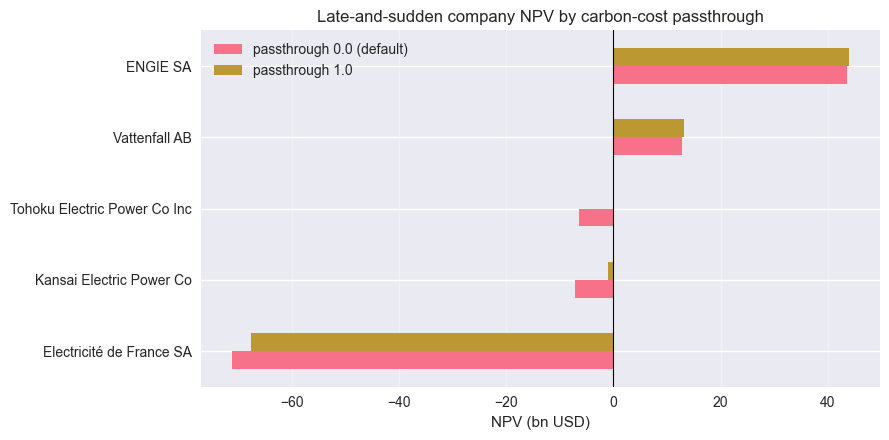

In [14]:
ax = comparison.plot.barh(figsize=(9, 4.5))
ax.set_title("Late-and-sudden company NPV by carbon-cost passthrough")
ax.set_xlabel("NPV (bn USD)")
ax.set_ylabel("")
ax.axvline(0, color="black", lw=0.8)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

Letting firms pass the carbon cost through moves every company's valuation in the
same direction, and moves the carbon-exposed ones most. The default of `0.0` is
deliberately the harsh end of that range: the model is a stress test, so it assumes
the firm eats the cost.

That is the shape of every parameter study with this model — change one key, re-run,
compare the same table. See `parameters.md` for the full list of keys and their
valid ranges.

In [15]:
# Leave data/fixture_run/ holding a default-parameter run, so anything that reads
# those files after this notebook sees the pinned regression numbers.
print(f"restored default run in {run_altr():.1f}s")

restored default run in 11.0s


## Where to go next

- **Run it on your own data** — `quickstart.md` covers preparing the three
  deliverables files and running without `--env fixture`.
- **Change the scenario pair** — `scenario_catalog.md` lists the available
  scenarios; set `baseline_scenario` and `target_scenario` in
  `conf/base/parameters.yml`.
- **Understand a single stage** — `pipelines/<stage>.md` gives its datasets, key
  functions and methodology references.
- **Get the plots** — drop `--tags altrisk` (or use `--tags reporting`) to run the
  reporting stage, which writes figures and export tables under `data/08_reporting/`.
- **See the graph** — `kedro viz run` opens an interactive map of the node graph.